In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset

In [ ]:
import kagglehub as kh

data_path = kh.dataset_download("kamilpytlak/personal-key-indicators-of-heart-disease")

df = pd.read_csv(data_path + "/2022/heart_2022_no_nans.csv")
df.shape

100%|██████████| 21.4M/21.4M [00:00<00:00, 84.9MB/s]

Extracting files...


(246022, 40)

In [ ]:
#device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
#print(f"Using {device} device")

In [ ]:
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,...,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246022 entries, 0 to 246021
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      246022 non-null  object 
 1   Sex                        246022 non-null  object 
 2   GeneralHealth              246022 non-null  object 
 3   PhysicalHealthDays         246022 non-null  float64
 4   MentalHealthDays           246022 non-null  float64
 5   LastCheckupTime            246022 non-null  object 
 6   PhysicalActivities         246022 non-null  object 
 7   SleepHours                 246022 non-null  float64
 8   RemovedTeeth               246022 non-null  object 
 9   HadHeartAttack             246022 non-null  object 
 10  HadAngina                  246022 non-null  object 
 11  HadStroke                  246022 non-null  object 
 12  HadAsthma                  246022 non-null  object 
 13  HadSkinCancer              24

In [ ]:
# categorical_cols = X.select_dtypes(include=['object']).columns
# numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

# categorical_cols
categorical_cols = X.select_dtypes(include = [object]).columns

numerical_cols = X.select_dtypes(include = ['int','float64']).columns
# categorical_cols
# numerical_cols

# preprocessing of X

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num',  numeric_transformer, numerical_cols),
    ('cat',  categorical_transformer, categorical_cols)
])

preprocessor
# preprocessor
X_transformed = preprocessor.fit_transform(X)
print(type(X_transformed))
print(X_transformed.shape)
print(len(preprocessor.get_feature_names_out()))

<class 'numpy.ndarray'>
(246022, 152)
152


In [ ]:
# seperate features from target
X = df.drop(columns=[ 'HadHeartAttack', 'HadAngina'])
Y = df[[ 'HadHeartAttack', 'HadAngina']].replace({"Yes": 1, "No": 0})


/tmp/ipykernel_2821/521678128.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = df[[ 'HadHeartAttack', 'HadAngina']].replace({"Yes": 1, "No": 0})


In [ ]:
# preprocessing of X

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])



In [ ]:
X_transformed = preprocessor.fit_transform(X)

print(type(X_transformed))
print(X_transformed.shape)
print(len(preprocessor.get_feature_names_out()))

<class 'numpy.ndarray'>
(246022, 152)
152


In [ ]:
Y
print(type(Y))
print(Y.shape)

<class 'numpy.ndarray'>
(246022, 2)


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_transformed,
    Y,
    test_size = 0.2,
    random_state = 42,
    stratify = Y
)


print ("Training_Set:", X_train.shape)
print ("Test_Set:", X_test.shape)
print ("Y_train_Set:", Y_train.shape)

Training_Set: (196817, 152)
Test_Set: (49205, 152)
Y_train_Set: (196817, 2)


In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
Y_train = torch.tensor(Y_train, dtype = torch.float32)
Y_test = torch.tensor(Y_test, dtype = torch.float32)
X_train.shape

/tmp/ipykernel_2821/3406660571.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipykernel_2821/3406660571.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype = torch.float32)
/tmp/ipykernel_2821/3406660571.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_train = torch.tensor(Y_train, dtype = torch.float32)
/tmp/ipykernel_2821/3406660571.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clon

torch.Size([196817, 152])

In [ ]:
# Step 1: Split into Train (70%) and Temp (30%)
X_train, X_test, Y_train, Y_test = train_test_split(
    X_transformed,
    Y,
    test_size=0.20,
    random_state=42,

)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Y_train set:", Y_train.shape)

Training set: (196817, 152)
Test set: (49205, 152)
Y_train set: (196817, 2)


In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)


In [ ]:
X_train.shape

torch.Size([196817, 152])

152

In [ ]:
#X_train = X_train.to(device)
#X_test = X_test.to(device)
#Y_train = Y_train.to(device)
#Y_test = Y_test.to(device)

In [ ]:
dataset = TensorDataset(X_train, Y_train)

# print(len(dataset))  # 100
print(dataset[0])

(tensor([-0.4900, -0.5143,  2.0675,  1.3581,  1.1201,  0.3994,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,
         1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,
         1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000,
         0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,
         1.0000,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,
         0.0000,  1.0000,  0.0000,  1.0

In [ ]:

# Create dataset
dataset = TensorDataset(X_train, Y_train)

print(len(dataset))  # 100
print(dataset[0])


196817
(tensor([-0.4900, -0.5143, -0.7089,  0.2330,  0.0138, -0.0826,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,
         1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,
         1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  1.0000,
         0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000,
         0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,
         0.0000,  1.0000,  0.000

In [ ]:
# # define neural model
# class NeuralNetwork(nn.Module):
#     def __init__(self):
#         super(NeuralNetwork, self).__init__()
#         self.flatten = nn.Flatten()

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

In [ ]:
# Define the model.
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 2),

)




In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
batch = 64

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
batch = 64

In [ ]:
from torch.utils.data import DataLoader

Loader = DataLoader(dataset, batch, shuffle=True)

#

In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=batch, shuffle=True)


In [ ]:
#model.to(device)


In [ ]:
Losses =  []

for epoch in range(epochs):
    for batch_X, batch_Y in Loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_Y)
        loss.backward()
        optimizer.step()
        Losses.append(loss.item())

    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item()}")

Epoch 1/50 - Loss: -0.0
Epoch 2/50 - Loss: 0.04337769001722336
Epoch 3/50 - Loss: 0.08176246285438538
Epoch 4/50 - Loss: 0.16445833444595337


KeyboardInterrupt: 

In [ ]:
losses = []

for epoch in range(epochs):
    for batch_X, batch_y in loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())


    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item()}")


Epoch 1/50 - Loss: 0.16136813163757324
Epoch 2/50 - Loss: 0.09680623561143875
Epoch 3/50 - Loss: -0.0
Epoch 4/50 - Loss: 0.06677955389022827
Epoch 5/50 - Loss: 0.08969452977180481
Epoch 6/50 - Loss: 0.09774938970804214
Epoch 7/50 - Loss: 0.1186884418129921
Epoch 8/50 - Loss: 0.07861699908971786
Epoch 9/50 - Loss: 0.1635693609714508
Epoch 10/50 - Loss: 0.06443961709737778
Epoch 11/50 - Loss: 0.1847008615732193
Epoch 12/50 - Loss: 0.07332795858383179
Epoch 13/50 - Loss: 0.08156794309616089
Epoch 14/50 - Loss: 0.03914140537381172
Epoch 15/50 - Loss: 0.0393352210521698
Epoch 16/50 - Loss: -0.0
Epoch 17/50 - Loss: 0.32959461212158203
Epoch 18/50 - Loss: 0.08243938535451889
Epoch 19/50 - Loss: -0.0
Epoch 20/50 - Loss: 0.09329943358898163
Epoch 21/50 - Loss: 0.08743011206388474
Epoch 22/50 - Loss: 0.11088033020496368
Epoch 23/50 - Loss: 0.08271139860153198
Epoch 24/50 - Loss: 0.00012866832548752427
Epoch 25/50 - Loss: 0.01095373835414648
Epoch 26/50 - Loss: 0.09891323745250702
Epoch 27/50 - L

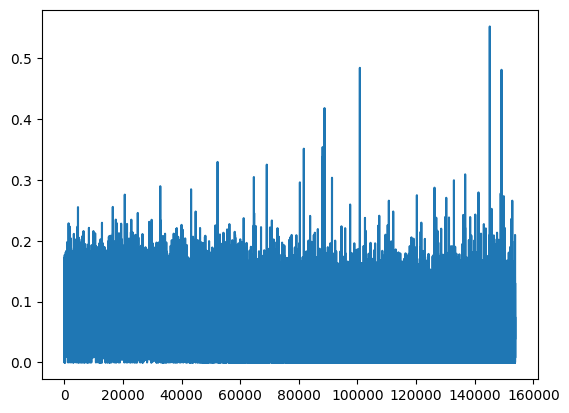

In [ ]:
plt.plot(losses)
plt.show()